In [132]:
#importaciones iniciales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

sns.set()

In [133]:
#carga del dataset desde el mismo kaggle
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "vehicles.csv"))

Using Colab cache for faster access to the 'craigslist-carstrucks-data' dataset.
['vehicles.csv']


Se usara `df.shape`para visaulizar cuantos registros van quedando luego de cada decisión de preprocesamiento.

In [134]:
#cntos registros y dimensionalida hay en un inicio
df.shape

(426880, 26)

In [135]:
#eliminamos la filas inutiles que no afectan al precio o que tienen muchso datos faltantes
df = df.drop(columns=['id', 'url', 'region_url', 'image_url', 'description', 'size', 'VIN', 'region', 'posting_date'])

Todas estas columnas tienen; o muchos datos faltantes o bien realmente no aportan al precio.

In [136]:
df.shape

(426880, 17)

In [137]:
#eliminamos la fila completa% vacia
df = df.drop(columns=['county'])

In [138]:
df.shape

(426880, 16)

In [139]:
#filtramos unicamente precio validos
df = df[df['price'] > 0]

Dado que los precios nulos o iguales a 0 dólares no sirven, nos quedamos únicamente con los válidos.

In [140]:
df.shape

(393985, 16)

In [141]:
#filtramos para no usar outlier
df = df[(df['price'] > 1000) & (df['price'] < 100000)]
df = df[(df['odometer'] > 0) & (df['odometer'] < 300000)]
df = df[(df['year'] > 1980) & (df['year'] <= 2024)]

Filtramos para no considerar outliers en el futuro modelo.

In [142]:
df.shape

(364151, 16)

In [143]:
#eliminaø de valores nulos

df = df.dropna(subset=['year', 'manufacturer', 'model', 'odometer'])

A pesar de que estas son las claves, los nulos que presentan son muy pocos y no baja drásticamente la cantidad de registros. Asimismo, mejora la calidad del dataset, por lo cual se prefiere calidad ante cantidad.
No se imputan dado que inventar años sería "peligroso", inventar modelos es imposible e inventar kilometrajes sesgaría.

In [144]:
df.shape

(349623, 16)

In [145]:
#imputaø de datos por unknown

cols_fill = ['condition', 'cylinders', 'drive', 'paint_color', 'type']

for col in cols_fill:
    df[col] = df[col].fillna('unknown')

Aquí sí imputamos para perder datos, meramente con la categoría `unknown`. Mantenemos la información y vemos si esta nueva categoria afectaría a la estimación del precio de los vehículos.

In [146]:
df.shape

(349623, 16)

In [147]:
df.shape

(349623, 16)

In [148]:
# imputaø x moda
df['fuel'] = df['fuel'].fillna(df['fuel'].mode()[0])
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

Imputaremos las varibles de alta cardinalidad por el valor más común de cada una. Se decide no eliminar o purgarlas dado que son varibales medianmetne críticas y no tienen muchos datos nulos, y no intruduce demasiado sesgo al modelo. Imputarlas con `unknown`sería introducir una categoría artificial "peligrosa", así que se decide hacer imputación simple.

In [149]:
df.shape

(349623, 16)

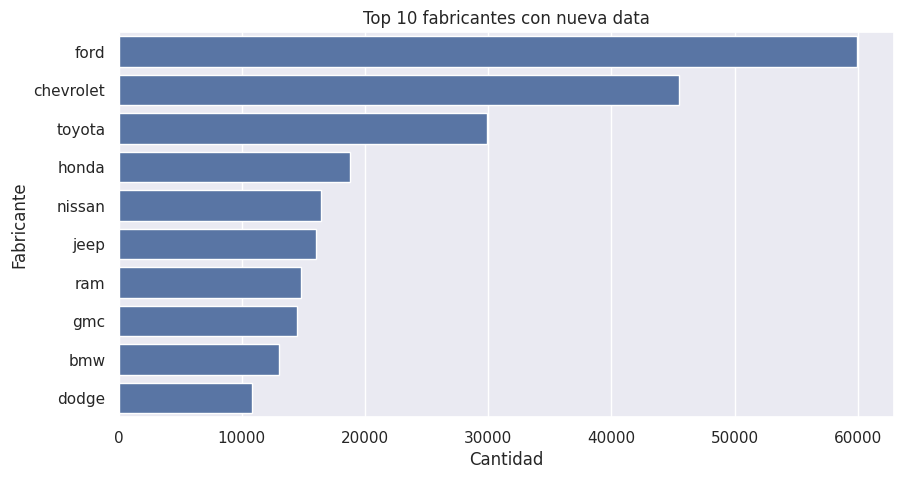

In [150]:
#visualizaø del top de fabricante luego de la elimanaø de filas

top_manufacturers = df['manufacturer'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index)
plt.title('Top 10 fabricantes con nueva data')
plt.xlabel('Cantidad')
plt.ylabel('Fabricante')
plt.show()

Como se aprecia, el dataset continua siendo dominado por los 3 colosos del mundo automtriz, ford, chevrolet y toyota, no obstante se han reducido los registros dada la limpieza realiza, por ejemplo paso de mas de 70mil registros en el eda, a solo unos 60mil; chevrolet, que tenía unos 55mil, ahora tiene unos 45mil, y toyota, de 35mil a 30mil.

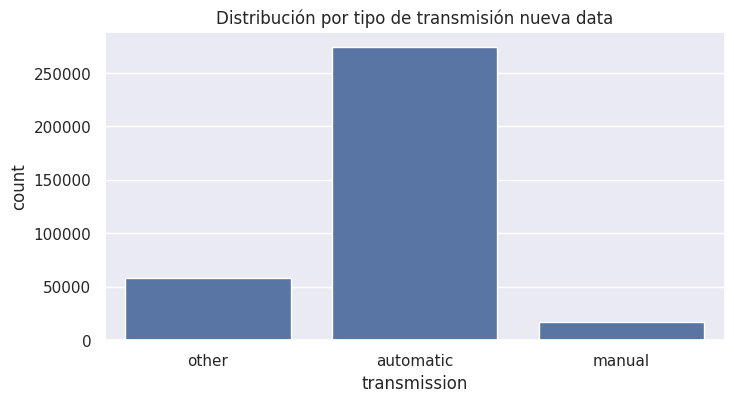

In [151]:
#visualizaø de transmiø luego de la elimanaø

plt.figure(figsize=(8,4))
sns.countplot(x='transmission', data=df)
plt.title('Distribución por tipo de transmisión nueva data')
plt.show()

De igual modo, las cantidades de cada tipo de transmisión disminuyen mas se mantienen las proporciones. Y, apesar del desbalance, se decide no realizar más procesamiento dado que no es crítico para una regresión.

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349623 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         349623 non-null  int64  
 1   year          349623 non-null  float64
 2   manufacturer  349623 non-null  object 
 3   model         349623 non-null  object 
 4   condition     349623 non-null  object 
 5   cylinders     349623 non-null  object 
 6   fuel          349623 non-null  object 
 7   odometer      349623 non-null  float64
 8   title_status  343913 non-null  object 
 9   transmission  349623 non-null  object 
 10  drive         349623 non-null  object 
 11  type          349623 non-null  object 
 12  paint_color   349623 non-null  object 
 13  state         349623 non-null  object 
 14  lat           346354 non-null  float64
 15  long          346354 non-null  float64
dtypes: float64(4), int64(1), object(11)
memory usage: 45.3+ MB


Vemos las columnas antes de la codificación de las varaibles categóricas.

In [153]:
#codificaø de variables categoricas
df = pd.get_dummies(df, columns=[
    'manufacturer',
    'fuel',
    'transmission',
    'type',
    'condition'
], drop_first=True)

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349623 entries, 27 to 426879
Data columns (total 76 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   price                         349623 non-null  int64  
 1   year                          349623 non-null  float64
 2   model                         349623 non-null  object 
 3   cylinders                     349623 non-null  object 
 4   odometer                      349623 non-null  float64
 5   title_status                  343913 non-null  object 
 6   drive                         349623 non-null  object 
 7   paint_color                   349623 non-null  object 
 8   state                         349623 non-null  object 
 9   lat                           346354 non-null  float64
 10  long                          346354 non-null  float64
 11  manufacturer_alfa-romeo       349623 non-null  bool   
 12  manufacturer_aston-martin     349623 non-null  b

Aquí tranformamos las variables categóricas a numéricas, dado que los computadores y algoritmos solo entienden de números... se hace en una escala entera del 0 hasta la cantidad de números pertienentes. Ademas dado que se usó `drop_first=True`se a "eliminado la primera categoria en orden alfabetico, dejandola para variable como categoria base, es decir, está implicita.

In [155]:
df.shape

(349623, 76)

In [156]:
#normalizaø con minmax para dejar valores entre 0 a 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['price', 'odometer', 'year']] = scaler.fit_transform(
    df[['price', 'odometer', 'year']]
)

Aqui aplicamos normalización para situar los datos de las variables numéricas; price, odometer y year; en el rango de 0 a 1. Se considero igualmente la tecnica de estandarizacion, descartada por centrar su proceso en la media de los datos. La normalización tiene mas compatbilidad con modelos sensibles a la escala como knn y redesneuronales. Asimismo, se debera invertir al escala de los valores de price uan vez aplicado el modelo para ver el valor d¿real de los vehiculos predichos.

In [157]:
df.shape

(349623, 76)

Como vemos se han introducido nuevas columnas al dataset dada la codificaión de las variables categóricas que se realizo.

In [158]:
#obtenø de las primeras filas del dataset limpio
#luego esto se ingresa a la carpeta data\processed del repositorio

df_processed_sample = df.head(10)

df_processed_sample.to_csv('datos_procesados_ejemplos.csv', index=False)

## nuevos gráficos
Procedo a generar nuevos gráficos para ver qué tal a quedado la data luego del preprocesamiento realizado, así como se generaron los dos anteriores de este mismo notebook.

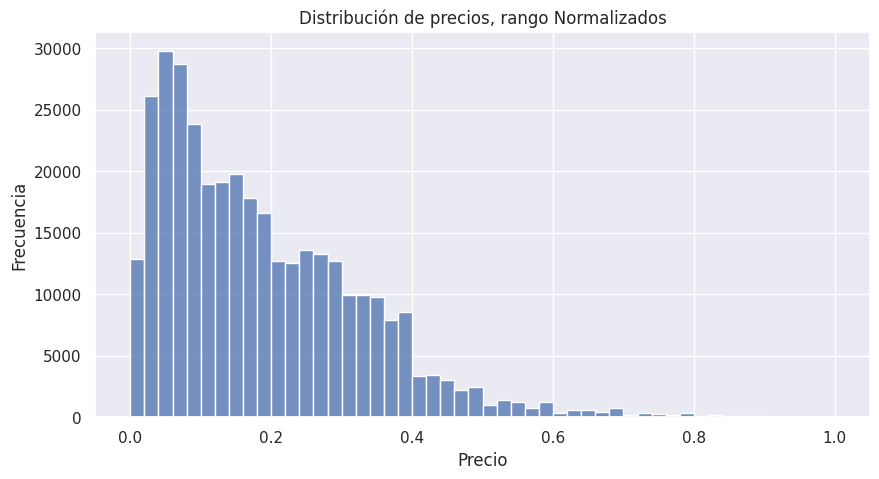

In [159]:
#distribucion de precios con nueva escala entre 0 a 1

plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50)
plt.title('Distribución de precios, rango Normalizados')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

Podemos ver que los precios mantienen su distribución, apesar de somneterse a minmax; que "comprime la mayoria y estira la cola" en la nueva escala.

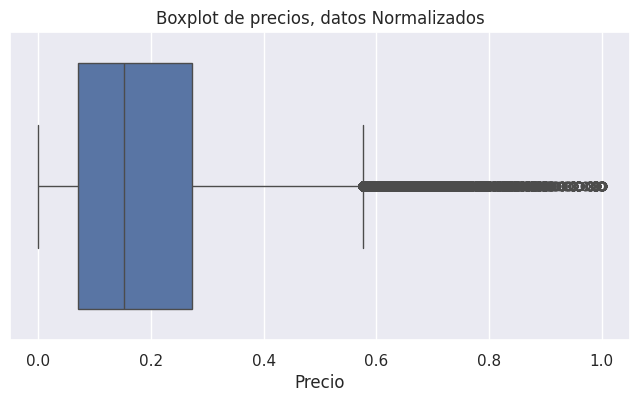

In [160]:
#boxplot precios

plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'])
plt.title('Boxplot de precios, datos Normalizados')
plt.xlabel('Precio')
plt.show()

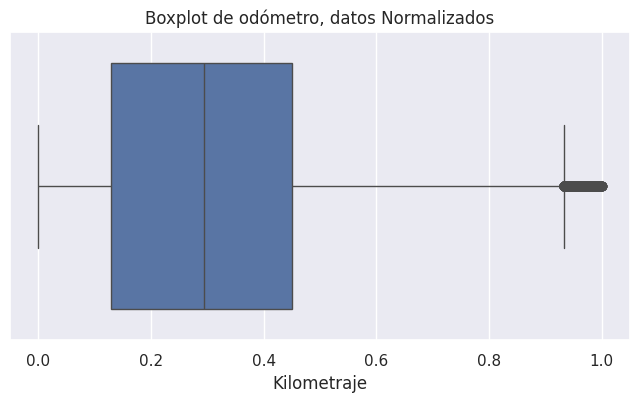

In [161]:
#boxplot odometro

plt.figure(figsize=(8,4))
sns.boxplot(x=df['odometer'])
plt.title('Boxplot de odómetro, datos Normalizados')
plt.xlabel('Kilometraje')
plt.show()

Podemos ver que en cuanto a los valores del odometro han aparecido lo que parecieran outliers, nop obstante son menos que un inicio, por lo cual no se trataran; justificado que serviran para que el modelo aprenda de vehiculos con un alto kilometraje.

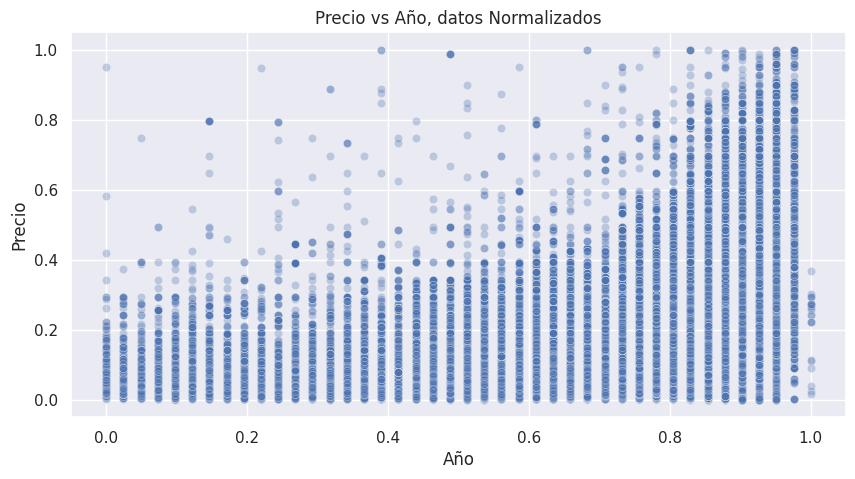

In [162]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='year', y='price', data=df, alpha=0.3)
plt.title('Precio vs Año, datos Normalizados')
plt.xlabel('Año')
plt.ylabel('Precio')
plt.show()

En este grafico de distribución podemos ver saltos entre los datos, dado que los años son un dato numérico discreto. Antes, en el EDA, la istancia entre un año y otro era practicamente imperceptible en el gráfico, ahora con los años normalizados se aprecia claramente la diferencia entre uno y otro.

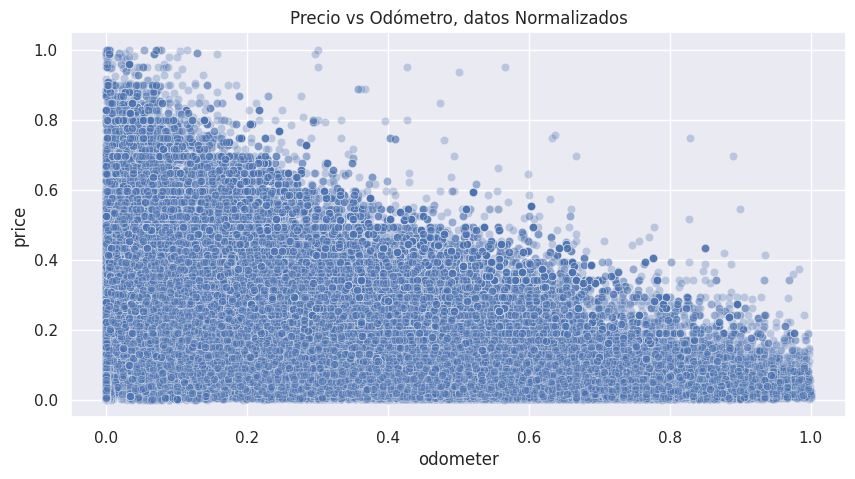

In [163]:
#grafico de precios vs odometro normalizado

plt.figure(figsize=(10,5))
sns.scatterplot(x='odometer', y='price', data=df, alpha=0.3)
plt.title('Precio vs Odómetro, datos Normalizados')
plt.show()

Igualmente, la distribucion practicamente no cambia, aun aplicada la normalización a estos datos.

In [164]:
#GUARDAR DATA PROCESADA

# 1. Guardar archivo en el entorno de Colab
file_name = "vehicles_processed.csv"
df.to_csv(file_name, index=False)

print(f"Archivo guardado en Colab como: {file_name}")

# 2. Descargar en  pc
from google.colab import files
files.download(file_name)


Archivo guardado en Colab como: vehicles_processed.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>